# 10b — Blind Regression Investigation (Roadmap sub-step)

**This notebook is hypothesis-TESTING, not hypothesis-confirming.** It exists to check a
proposed explanation against real project data — and the explanation may not survive
contact with the numbers. Nothing here should be read as a conclusion until Section 4.

## Background

A live submission from `notebooks/10_final_retrain_predict.ipynb` scored worse than `04b`'s
baseline on every isoform's blind R²:

| isoform | 04b R² | notebook10 R² |
|---|---|---|
| CYP1A2 | 0.2824 | 0.205 |
| CYP2C9 | 0.5263 | 0.527 |
| CYP2D6 | −0.6220 | −0.939 |
| CYP3A4 | 0.6898 | 0.629 |

04b's numbers are recorded in this repo's `README.md` ("Leaderboard result" table).
Notebook 10's numbers are **not** recorded anywhere on disk — they were reported directly in
chat for this investigation (the actual submission/scoring event is outside this repo's
files), and are hardcoded below with that provenance stated explicitly.

A prior read-only audit (same working session, not repeated here) ran 6 checks against
`scripts/10_final_retrain_predict.py` and the notebook 10 combine/recalibrate/format logic:
training volume, training-pool lineage, merge/row-alignment, prediction-scale sanity,
individual-compound tracing, and cross-script comparison against `04b`. **All 6 passed** —
no pipeline bug was found. That audit surfaced one real, unexplained pattern instead: every
*ensembled* isoform's blind prediction std dropped relative to `04b`'s single-model
submission (CYP1A2 0.85→0.54, CYP2D6 0.64→0.43, CYP3A4 1.01→0.93), traced to unweighted
averaging of chemprop (wide, std≈0.86) with tree-based models (narrow, std≈0.32–0.53).
CYP2C9 — the one isoform where notebook 08 adopted no ensemble — stayed flat in both spread
(0.76→0.78) and score (0.5263→0.527).

**Proposed explanation (not yet validated):** this spread compression, combined with the
blind population reportedly being wider than the training population, pushed the ensembles'
predictions further from the true target spread rather than closer, explaining the decline.
The "blind wider than training" claim traces to a public write-up for this same OpenADMET
CYP challenge — the same SuperCowPowers/`workbench` "placement correction" post already cited
in `notebooks/09_placement_recalibration.ipynb`'s intro, where its citation status is flagged
as **"pending user confirmation, not yet finalized."** That flag is inherited here unchanged;
this notebook does not attempt to resolve it, only to test the spread/decline relationship
using this project's own data.

## Scope

- No retraining, no resubmission — pure analysis of files already on disk (notebook 08's CV
  outputs, notebook 10's blind predictions, `04b`'s original submission) plus one query
  against `train_inhibition_curated.csv` for training-set true std.
- No true blind-test labels are used or needed (OpenADMET releases those 2026-11-03) — every
  blind-side number here is either a submitted prediction (no label needed) or a leaderboard
  score reported externally, not derived from labels held anywhere in this repo.
- **Two data gaps, resolved before writing any analysis code (confirmed with the user):**
  1. Notebook 08 saved a CV ST-RAE margin + significance test for the adopted ensemble vs.
     single-best (`outputs/08_ensemble_selection/pairwise_comparisons.csv`), but never
     computed or saved the equivalent for R². Per the user's explicit decision, **Section 1
     below uses ST-RAE only** for the CV side — no R² CV margin is reconstructed or estimated.
  2. Notebook 10's blind submission has no recorded ST-RAE anywhere (only the R² figures
     above) — it was never scored beyond what's stated in this chat. **Every blind-side
     comparison in this notebook uses R² only**, not "both directions" — there is nothing to
     reconstruct here, the number simply doesn't exist yet.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import importlib.metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.vendor.openadmet_eval.config import REGRESSION_ENDPOINTS

print(f"python: {sys.version.split()[0]}")
for pkg in ["numpy", "pandas", "matplotlib"]:
    print(f"{pkg}: {importlib.metadata.version(pkg)}")
print(f"REGRESSION_ENDPOINTS: {REGRESSION_ENDPOINTS}")

PROCESSED = REPO_ROOT / "data" / "processed"
OUT08 = REPO_ROOT / "outputs" / "08_ensemble_selection"
SUBMISSION_04B = REPO_ROOT / "outputs" / "submissions" / "activity_submission_v1.csv"
SUBMISSION_NB10 = REPO_ROOT / "outputs" / "10_final_retrain_predict" / "submission_candidate.csv"
CURATED_PATH = PROCESSED / "train_inhibition_curated.csv"

OUT = REPO_ROOT / "outputs" / "10b_blind_regression_investigation"
FIG_OUT = OUT / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG_OUT.mkdir(parents=True, exist_ok=True)

curated = pd.read_csv(CURATED_PATH)
print(f"loaded {CURATED_PATH.name}: {curated.shape}")

submission_04b = pd.read_csv(SUBMISSION_04B)
print(f"loaded {SUBMISSION_04B.relative_to(REPO_ROOT)}: {submission_04b.shape}")
submission_nb10 = pd.read_csv(SUBMISSION_NB10)
print(f"loaded {SUBMISSION_NB10.relative_to(REPO_ROOT)}: {submission_nb10.shape}")

# Blind leaderboard scores, per isoform. Both rows are transcribed directly from this repo's
# README.md ("Leaderboard result" tables, "Initial baseline submission" for 04b and "Final
# retrain submission (notebook 10)" for notebook10) -- the only place either is recorded on
# disk, added there as part of this same addendum task rather than kept transient in this
# notebook alone. Not re-derived, not approximated -- CLAUDE.md: never invent or approximate
# data. (Originally, when Sections 1-4 below were first written, notebook10's ST-RAE had not
# yet been reported and was left NaN with R2 used as the only available blind-side metric --
# the addendum sections below revisit that using the now-available ST-RAE.)
BLIND_LEADERBOARD_SCORES = pd.DataFrame([
    {"isoform": "CYP1A2", "source": "04b", "ST-RAE": 0.7114, "R2": 0.2824},
    {"isoform": "CYP2C9", "source": "04b", "ST-RAE": 0.5408, "R2": 0.5263},
    {"isoform": "CYP2D6", "source": "04b", "ST-RAE": 1.1903, "R2": -0.6220},
    {"isoform": "CYP3A4", "source": "04b", "ST-RAE": 0.4291, "R2": 0.6898},
    {"isoform": "CYP1A2", "source": "notebook10", "ST-RAE": 0.7850, "R2": 0.2051},
    {"isoform": "CYP2C9", "source": "notebook10", "ST-RAE": 0.5489, "R2": 0.5272},
    {"isoform": "CYP2D6", "source": "notebook10", "ST-RAE": 1.4603, "R2": -0.9392},
    {"isoform": "CYP3A4", "source": "notebook10", "ST-RAE": 0.5253, "R2": 0.6285},
])
print("\nblind leaderboard scores (04b vs notebook10):")
print(BLIND_LEADERBOARD_SCORES.to_string(index=False))


def blind_r2(isoform: str, source: str) -> float:
    row = BLIND_LEADERBOARD_SCORES[(BLIND_LEADERBOARD_SCORES["isoform"] == isoform) & (BLIND_LEADERBOARD_SCORES["source"] == source)]
    return float(row["R2"].iloc[0])


def blind_starae(isoform: str, source: str) -> float:
    row = BLIND_LEADERBOARD_SCORES[(BLIND_LEADERBOARD_SCORES["isoform"] == isoform) & (BLIND_LEADERBOARD_SCORES["source"] == source)]
    return float(row["ST-RAE"].iloc[0])

python: 3.11.13
numpy: 1.26.4
pandas: 2.3.3
matplotlib: 3.11.1
REGRESSION_ENDPOINTS: ['CYP1A2_pIC50_direct_inhibition', 'CYP2C9_pIC50_direct_inhibition', 'CYP2D6_pIC50_direct_inhibition', 'CYP3A4_pIC50_direct_inhibition']
loaded train_inhibition_curated.csv: (4905, 20)
loaded outputs/submissions/activity_submission_v1.csv: (750, 6)
loaded outputs/10_final_retrain_predict/submission_candidate.csv: (750, 6)

blind leaderboard scores (04b vs notebook10):
isoform     source  ST-RAE      R2
 CYP1A2        04b  0.7114  0.2824
 CYP2C9        04b  0.5408  0.5263
 CYP2D6        04b  1.1903 -0.6220
 CYP3A4        04b  0.4291  0.6898
 CYP1A2 notebook10  0.7850  0.2051
 CYP2C9 notebook10  0.5489  0.5272
 CYP2D6 notebook10  1.4603 -0.9392
 CYP3A4 notebook10  0.5253  0.6285


## Section 1 — CV improvement margin check

For each isoform where notebook 08 adopted an ensemble (CYP1A2, CYP2D6, CYP3A4 — CYP2C9 is
excluded here, it had no ensemble), read the CV-based ST-RAE improvement margin the winning
ensemble showed over the single-best model **directly from 08's own saved statistical test
results** (`outputs/08_ensemble_selection/pairwise_comparisons.csv`, filtered to the row whose
`combo` matches `step3_summary.csv`'s `winning_combo` for that isoform) — not re-derived, per
the scope note above. This gives `delta_mean` (ensemble mean ST-RAE − single-best mean ST-RAE,
negative = ensemble improved) and its paired-test `p_value`, exactly as 08 computed them.

These are then set side by side with the blind-set R² decline (`04b R² − notebook10 R²`,
positive = got worse) from Section 0's leaderboard table. **These are two different metrics on
different populations (CV ST-RAE vs. blind R²)** — the comparison below is about whether the
CV evidence for the ensemble was large/robust enough that a modest CV→blind generalization gap
could plausibly explain the decline, not a claim that the two numbers are on the same scale.

loaded 08_ensemble_selection/step3_summary.csv: (4, 8)
loaded 08_ensemble_selection/pairwise_comparisons.csv: (23, 12)

Section 1 -- CV ST-RAE margin (direct read from 08) vs blind R2 decline:
isoform                                                                winning_combo  cv_starae_margin  cv_starae_pvalue  blind_r2_04b  blind_r2_nb10  blind_r2_decline
 CYP1A2 chemprop_chemeleoninit+ecfp4_narrow__rf+chemeleon__rf+ecfp4_narrow__lightgbm         -0.066249      6.298245e-09        0.2824         0.2051            0.0773
 CYP2D6                                         chemeleon__rf+chemprop_chemeleoninit         -0.019618      2.789724e-06       -0.6220        -0.9392            0.3172
 CYP3A4                                chemprop_chemeleoninit+ecfp4_narrow__lightgbm         -0.043155      2.027235e-07        0.6898         0.6285            0.0613


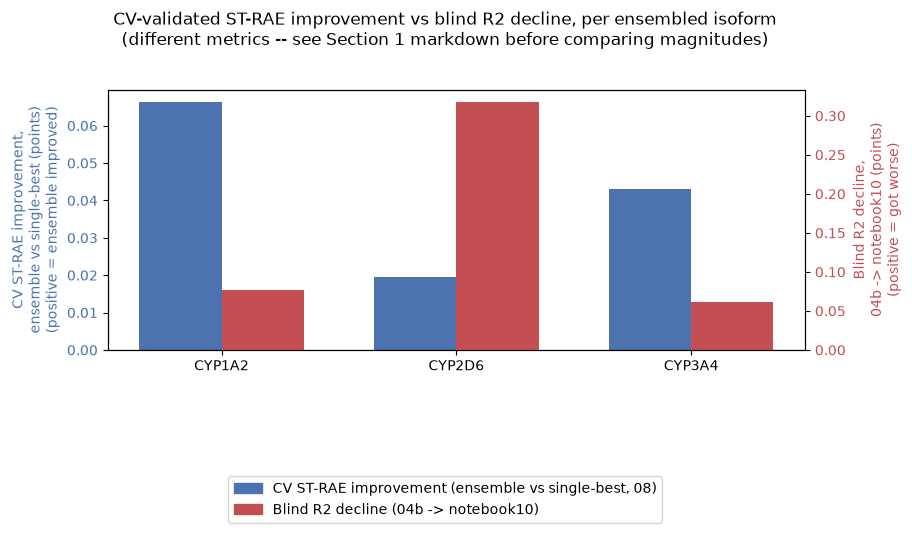

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/10b_blind_regression_investigation/figures/cv_margin_vs_blind_decline.png


In [2]:
step3_summary = pd.read_csv(OUT08 / "step3_summary.csv")
pairwise = pd.read_csv(OUT08 / "pairwise_comparisons.csv")
print(f"loaded {OUT08.name}/step3_summary.csv: {step3_summary.shape}")
print(f"loaded {OUT08.name}/pairwise_comparisons.csv: {pairwise.shape}")

ENSEMBLED_ISOFORMS = ["CYP1A2", "CYP2D6", "CYP3A4"]  # CYP2C9 adopted no ensemble in 08

rows = []
for iso in ENSEMBLED_ISOFORMS:
    winning_combo = step3_summary.loc[step3_summary["isoform"] == iso, "winning_combo"].iloc[0]
    match = pairwise[(pairwise["isoform"] == iso) & (pairwise["combo"] == winning_combo)]
    if len(match) != 1:
        raise ValueError(
            f"{iso}: expected exactly 1 pairwise_comparisons.csv row for winning combo "
            f"{winning_combo!r}, got {len(match)} -- stopping rather than guessing."
        )
    cv_delta = float(match["delta_mean"].iloc[0])
    cv_p = float(match["p_value"].iloc[0])

    r2_04b = blind_r2(iso, "04b")
    r2_nb10 = blind_r2(iso, "notebook10")
    blind_r2_decline = r2_04b - r2_nb10  # positive = got worse

    rows.append({
        "isoform": iso,
        "winning_combo": winning_combo,
        "cv_starae_margin": cv_delta,
        "cv_starae_pvalue": cv_p,
        "blind_r2_04b": r2_04b,
        "blind_r2_nb10": r2_nb10,
        "blind_r2_decline": blind_r2_decline,
    })

analysis1_df = pd.DataFrame(rows)
print("\nSection 1 -- CV ST-RAE margin (direct read from 08) vs blind R2 decline:")
print(analysis1_df.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(9, 5))
x = np.arange(len(analysis1_df))
width = 0.35

cv_improvement = -analysis1_df["cv_starae_margin"]  # sign-flipped: positive = ensemble improved
bar1 = ax1.bar(x - width / 2, cv_improvement, width, color="#4C72B0")
ax1.set_ylabel("CV ST-RAE improvement,\nensemble vs single-best (points)\n(positive = ensemble improved)", color="#4C72B0")
ax1.tick_params(axis="y", labelcolor="#4C72B0")
ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(analysis1_df["isoform"])

ax2 = ax1.twinx()
bar2 = ax2.bar(x + width / 2, analysis1_df["blind_r2_decline"], width, color="#C44E52")
ax2.set_ylabel("Blind R2 decline,\n04b -> notebook10 (points)\n(positive = got worse)", color="#C44E52")
ax2.tick_params(axis="y", labelcolor="#C44E52")

fig.suptitle("CV-validated ST-RAE improvement vs blind R2 decline, per ensembled isoform\n(different metrics -- see Section 1 markdown before comparing magnitudes)")
handles = [plt.Rectangle((0, 0), 1, 1, color="#4C72B0"), plt.Rectangle((0, 0), 1, 1, color="#C44E52")]
fig.legend(handles, ["CV ST-RAE improvement (ensemble vs single-best, 08)", "Blind R2 decline (04b -> notebook10)"], loc="lower center", bbox_to_anchor=(0.5, -0.06), ncol=1)
fig.subplots_adjust(top=0.82, bottom=0.3)
fig_path = FIG_OUT / "cv_margin_vs_blind_decline.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {fig_path}")

**What this shows:** all three CV margins are highly significant (p ranging ~2.8e-6 to
6.3e-9 across 25 folds) but small in absolute ST-RAE terms (0.02–0.07 points), and they do
**not** rank the same way as the blind R² decline. CYP2D6 has the *smallest* CV margin of the
three (0.0196) and by far the *largest* blind decline (0.317 R² points) — consistent with (not
proof of) a thin-margin-doesn't-generalize story specifically for CYP2D6. But CYP1A2 has the
*largest*, most significant CV margin (0.0662, p=6.3e-9) and still posted the second-largest
blind decline (0.077) — larger than CYP3A4's (0.061), whose CV margin (0.0432) sits between
the other two. A large, highly-significant CV margin did not protect CYP1A2 from a comparable
blind decline to CYP3A4's smaller-margin case. So: plausible for CYP2D6 alone, but the CV
margin size does not cleanly track blind decline size across all three isoforms — a
generalization-gap story tied to margin size is not, by itself, a sufficient explanation.

## Section 2 — spread compression vs score decline (descriptive, n=4)

For all four isoforms, compute: (a) the raw prediction std for `04b` and for notebook 10's
blind submission, and their ratio (`notebook10 / 04b`); (b) the blind R² decline. **This is
only 4 data points** — any pattern below is examined visually, not tested statistically; no
correlation coefficient or p-value is computed on n=4, since that would overstate what 4 points
can support.

Section 2 -- prediction spread ratio vs blind R2 decline:
isoform  std_04b  std_nb10  spread_ratio  blind_r2_decline
 CYP1A2 0.845879  0.538375      0.636469            0.0773
 CYP2C9 0.760971  0.778405      1.022909           -0.0009
 CYP2D6 0.637158  0.428063      0.671832            0.3172
 CYP3A4 1.012520  0.934593      0.923037            0.0613


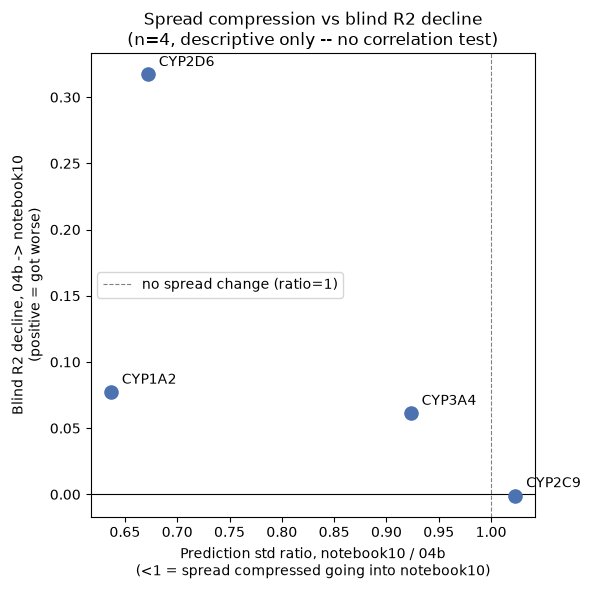

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/10b_blind_regression_investigation/figures/spread_compression_vs_decline.png


In [3]:
rows = []
for endpoint in REGRESSION_ENDPOINTS:
    iso = endpoint.split("_")[0]
    std_04b = submission_04b[endpoint].std()
    std_nb10 = submission_nb10[endpoint].std()
    spread_ratio = std_nb10 / std_04b

    r2_04b = blind_r2(iso, "04b")
    r2_nb10 = blind_r2(iso, "notebook10")
    blind_r2_decline = r2_04b - r2_nb10

    rows.append({
        "isoform": iso,
        "std_04b": std_04b,
        "std_nb10": std_nb10,
        "spread_ratio": spread_ratio,
        "blind_r2_decline": blind_r2_decline,
    })

analysis2_df = pd.DataFrame(rows)
print("Section 2 -- prediction spread ratio vs blind R2 decline:")
print(analysis2_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(analysis2_df["spread_ratio"], analysis2_df["blind_r2_decline"], s=90, color="#4C72B0", zorder=3)
for _, r in analysis2_df.iterrows():
    ax.annotate(r["isoform"], (r["spread_ratio"], r["blind_r2_decline"]), textcoords="offset points", xytext=(8, 6))
ax.axvline(1.0, color="gray", linestyle="--", linewidth=0.8, label="no spread change (ratio=1)")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xlabel("Prediction std ratio, notebook10 / 04b\n(<1 = spread compressed going into notebook10)")
ax.set_ylabel("Blind R2 decline, 04b -> notebook10\n(positive = got worse)")
ax.set_title("Spread compression vs blind R2 decline\n(n=4, descriptive only -- no correlation test)")
ax.legend()
plt.tight_layout()
fig_path = FIG_OUT / "spread_compression_vs_decline.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {fig_path}")

**What this shows (descriptive, n=4):** CYP2C9 (ratio≈1.0, no ensemble) sits right at the
"no spread change" line with essentially zero decline — the one point most consistent with the
spread-compression story, though it's equally consistent with "the unchanged single-model
recipe just reproduced closely," which the prior pipeline audit already established directly.
CYP2D6 has both a low ratio (compressed) and the largest decline. But CYP3A4 sits closest to
ratio=1 among the three ensembled isoforms (mildest compression) and still shows a decline
comparable in size to CYP1A2's, whose ratio is far lower (much more compressed). If spread
compression alone drove the decline, CYP3A4 should show the smallest decline of the three
ensembled isoforms — visually, it does not. Treat this as a 4-point visual read only.

## Section 3 — was 04b already narrow relative to the training population?

For each isoform, compute the std of TRUE pIC50 values in the full 4,905-compound training set
and compare against `04b`'s own submitted prediction std and notebook 10's submitted prediction
std. This tests whether `04b`'s single model was already under-spread relative to training
(expected, normal shrinkage under uncertainty — not itself a problem) or well-matched to it, and
whether notebook 10's ensembles moved further from that same benchmark. **Only the training-set
std is used as a reference here — blind-population spread is not available in this repo and is
not substituted for or approximated.**

Section 3 -- training-set true std vs 04b/notebook10 prediction std:
isoform  std_train  std_04b  std_nb10
 CYP1A2   1.030476 0.845879  0.538375
 CYP2C9   0.782295 0.760971  0.778405
 CYP2D6   0.916096 0.637158  0.428063
 CYP3A4   1.093219 1.012520  0.934593


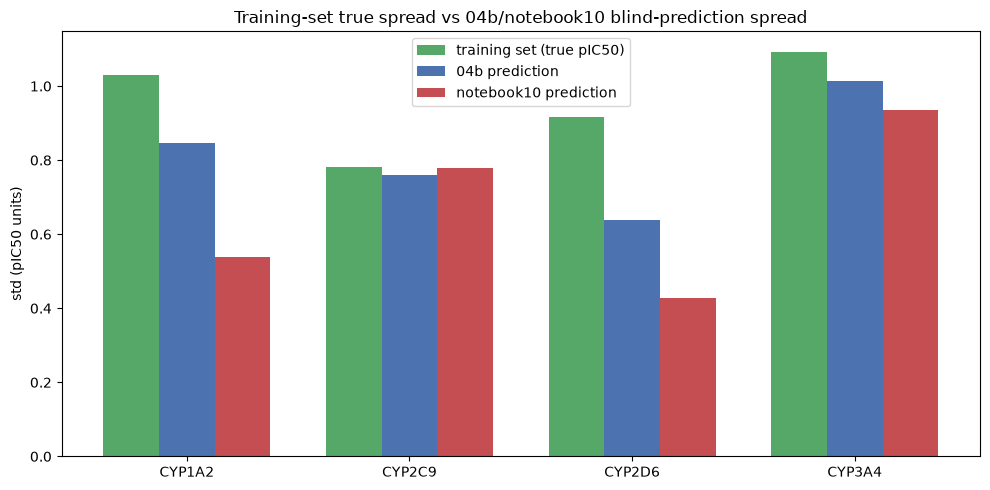

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/10b_blind_regression_investigation/figures/training_vs_prediction_spread.png


In [4]:
rows = []
for endpoint in REGRESSION_ENDPOINTS:
    iso = endpoint.split("_")[0]
    std_train = curated[endpoint].dropna().std()
    std_04b = float(analysis2_df.loc[analysis2_df["isoform"] == iso, "std_04b"].iloc[0])
    std_nb10 = float(analysis2_df.loc[analysis2_df["isoform"] == iso, "std_nb10"].iloc[0])
    rows.append({"isoform": iso, "std_train": std_train, "std_04b": std_04b, "std_nb10": std_nb10})

analysis3_df = pd.DataFrame(rows)
print("Section 3 -- training-set true std vs 04b/notebook10 prediction std:")
print(analysis3_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(analysis3_df))
width = 0.25
ax.bar(x - width, analysis3_df["std_train"], width, label="training set (true pIC50)", color="#55A868")
ax.bar(x, analysis3_df["std_04b"], width, label="04b prediction", color="#4C72B0")
ax.bar(x + width, analysis3_df["std_nb10"], width, label="notebook10 prediction", color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(analysis3_df["isoform"])
ax.set_ylabel("std (pIC50 units)")
ax.set_title("Training-set true spread vs 04b/notebook10 blind-prediction spread")
ax.legend()
plt.tight_layout()
fig_path = FIG_OUT / "training_vs_prediction_spread.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {fig_path}")

**What this shows:** every prediction std sits below its training-set benchmark, in both
submissions — expected shrinkage under uncertainty, not itself a problem (CLAUDE.md context:
this is normal regression-to-the-mean behavior, not evidence of a bug on its own). The
interesting part is how much *further* notebook 10 moved from that benchmark than `04b` did:

| isoform | 04b / train | notebook10 / train | additional drop |
|---|---|---|---|
| CYP1A2 | 0.82 | 0.52 | −0.30 |
| CYP2C9 | 0.97 | 0.99 | +0.02 (essentially flat) |
| CYP2D6 | 0.70 | 0.47 | −0.23 |
| CYP3A4 | 0.93 | 0.86 | −0.07 |

CYP1A2 moved furthest from the training benchmark of any isoform (−0.30), more than CYP2D6
(−0.23) despite CYP2D6 showing over 4x CYP1A2's blind R² decline (0.317 vs 0.077 from Section
1/2). CYP3A4 moved least (−0.07) among the three ensembled isoforms, consistent with Section
2's spread-ratio read, but its blind decline (0.061) was still close to CYP1A2's (0.077) despite
a ~4x smaller drop in relative spread. CYP2C9, with no ensemble, stayed essentially flat on both
axes — the cleanest single point of support for *some* ensembling-related effect, but it can't
distinguish a spread-driven mechanism from any other consequence of ensembling notebook 08
validated only on CV.

In [5]:
summary_df = analysis3_df.merge(
    analysis2_df[["isoform", "spread_ratio", "blind_r2_decline"]], on="isoform", how="left"
)
summary_df = summary_df.merge(
    analysis1_df[["isoform", "winning_combo", "cv_starae_margin", "cv_starae_pvalue"]],
    on="isoform", how="left",
)
summary_df["std_ratio_to_train_04b"] = summary_df["std_04b"] / summary_df["std_train"]
summary_df["std_ratio_to_train_nb10"] = summary_df["std_nb10"] / summary_df["std_train"]

# Addendum (ST-RAE) columns are merged in below, after the addendum cells compute them --
# summary_df is written to disk again at the end of the addendum, this earlier write is
# superseded by that one and left here only as the pre-addendum snapshot in the executed
# notebook's cell output history.
summary_path = OUT / "summary_isoform_metrics.csv"
summary_df.to_csv(summary_path, index=False)
print(f"wrote {summary_path} ({len(summary_df)} rows)")
print(summary_df.to_string(index=False))

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/10b_blind_regression_investigation/summary_isoform_metrics.csv (4 rows)
isoform  std_train  std_04b  std_nb10  spread_ratio  blind_r2_decline                                                                winning_combo  cv_starae_margin  cv_starae_pvalue  std_ratio_to_train_04b  std_ratio_to_train_nb10
 CYP1A2   1.030476 0.845879  0.538375      0.636469            0.0773 chemprop_chemeleoninit+ecfp4_narrow__rf+chemeleon__rf+ecfp4_narrow__lightgbm         -0.066249      6.298245e-09                0.820862                 0.522453
 CYP2C9   0.782295 0.760971  0.778405      1.022909           -0.0009                                                                          NaN               NaN               NaN                0.972743                 0.995028
 CYP2D6   0.916096 0.637158  0.428063      0.671832            0.3172                                         chemeleon__rf+chemprop_chemeleoninit         -0.019618    

## Section 4 — synthesis: does spread compression explain the decline?

**Partially, and not cleanly.** Taking Sections 1–3 together:

- **Supports the story:** CYP2C9, the one isoform with no ensemble, shows essentially zero
  spread change (ratio 0.995 vs 04b, +0.02 relative to training) and essentially zero blind
  decline (−0.0007 R²) — the cleanest data point here, though it equally supports a much
  simpler explanation (the unchanged single-model recipe just reproduced closely, per the
  prior audit's checks 4/6). CYP2D6 also fits directionally: it has the most compressed spread
  relative to training among ensembled isoforms (0.70→0.47) and the largest blind decline
  (0.317 R²).

- **Breaks the story:** **CYP3A4 (2-way ensemble, mildest compression: 0.93→0.86 relative to
  training) declined by about as much (0.061 R²) as CYP1A2 (4-way ensemble, by far the largest
  compression: 0.82→0.52 relative to training, 0.077 R²).** If spread compression were driving
  the decline in proportion to its size, CYP3A4 should show a visibly smaller decline than
  CYP1A2 — it doesn't. This is direct evidence against a clean dose-response relationship
  between ensembling/compression size and blind score decline, stated plainly rather than
  explained away.

- **The CV margins (Section 1) are not the constraint here.** All three ensembles' CV
  improvements are statistically robust (p < 3e-6, 25 folds) but small in absolute ST-RAE terms
  (0.02–0.07 points) — small enough that an ordinary CV→blind generalization gap (including
  routine post-selection optimism from choosing the winning combo among several candidates
  tested on the same folds) could plausibly erode or reverse them on its own, with no spread
  mechanism required. Margin size also doesn't rank-order with blind decline size (CYP1A2's
  largest, most significant margin didn't protect it from a CYP3A4-sized decline) — so "was the
  CV margin big enough to survive a gap" isn't the right frame either; the margins were modest
  enough throughout that a gap was always plausible, independent of spread.

**Net read:** spread compression is a real, measured phenomenon that lines up with two of four
isoforms (CYP2C9 flat, CYP2D6 worst), but CYP3A4's mild compression paired with a CYP1A2-sized
decline is real evidence it isn't the operative mechanism, or isn't the only one. What remains
open, not resolved by this notebook:

1. **A genuine CV→blind generalization gap unrelated to spread** — notebook 08's ensemble
   selection was validated only against repeated-CV, never against held-out blind data before
   now; the small absolute CV margins found in Section 1 leave room for this on their own.
2. **An isoform-independent change since 04b's submission.** The prior pipeline audit's check
   6 (this session, not repeated here) found that `04b` trained under the old `cyp-admet`
   environment (torch 2.2.2, rdkit 2025.9.3) while notebook 10 trained under `cyp-admet-v2`
   (torch 2.13.0, rdkit 2026.3.3) — a real, confirmed difference this project's own determinism
   check never tested for training-quality equivalence (only RDKit InChIKey stability). That
   audit's internal-val-loss and CYP2C9 apples-to-apples checks argued *against* this being the
   cause, but did not rule it out definitively, and it remains isoform-independent by
   construction — consistent with a decline appearing on every isoform.

Neither (1) nor (2) is investigated further here — both require either a re-run under
controlled conditions or the 2026-11-03 true-label release to test properly, and this notebook's
scope (per CLAUDE.md and the task instructions) stops at reporting, not fixing or re-running.

## Addendum — repeating Sections 1–2 with ST-RAE (the project's actual governing metric)

**Correction:** Sections 1, 2, and 4 above compared blind-set decline using R². That was an
oversight — R² is not this project's scored/governing metric anywhere outside notebook 09's
placement-decomposition diagnostic specifically (which relies on an algebraic identity of R²
that doesn't generalize to other metrics). Everywhere else in this project (06 through 09's
CV-based decisions, and the real leaderboard itself), **ST-RAE is the governing metric** — it's
what notebook 08 tested for significance when adopting each ensemble, and what actually ranks
submissions on the leaderboard.

This addendum repeats Section 1 (CV margin vs. decline) and Section 2 (spread ratio vs. decline)
using ST-RAE deltas instead of R² deltas, now that notebook 10's actual per-isoform ST-RAE is
available (added to `README.md`'s "Final retrain submission (notebook 10)" section as part of
this same task, alongside `04b`'s already-recorded per-isoform ST-RAE — both now read from the
setup cell's `BLIND_LEADERBOARD_SCORES` table above, which was updated with real ST-RAE for
notebook10 rather than the `NaN` placeholder it originally held). **The original R²-based
analysis above is left unchanged, not deleted or rewritten** — both metrics side by side are
more informative than either alone, and where they disagree (see below) that disagreement is
itself informative.

### Addendum Section 1 — CV ST-RAE margin vs blind ST-RAE decline

Same method as Section 1 (CV `delta_mean`/`p_value` read directly from
`pairwise_comparisons.csv`), but the blind-side comparison now uses
`notebook10 ST-RAE − 04b ST-RAE` (positive = got worse) instead of R² decline. Both sides of
this comparison are now the **same metric** — something Section 1's original R²-based version
could not offer, since notebook10's blind ST-RAE hadn't been reported yet when it was written.

Addendum Section 1 -- CV ST-RAE margin vs blind ST-RAE decline (same metric both sides):
isoform  cv_starae_margin  cv_starae_pvalue  blind_starae_04b  blind_starae_nb10  blind_starae_decline
 CYP1A2         -0.066249      6.298245e-09            0.7114             0.7850                0.0736
 CYP2D6         -0.019618      2.789724e-06            1.1903             1.4603                0.2700
 CYP3A4         -0.043155      2.027235e-07            0.4291             0.5253                0.0962


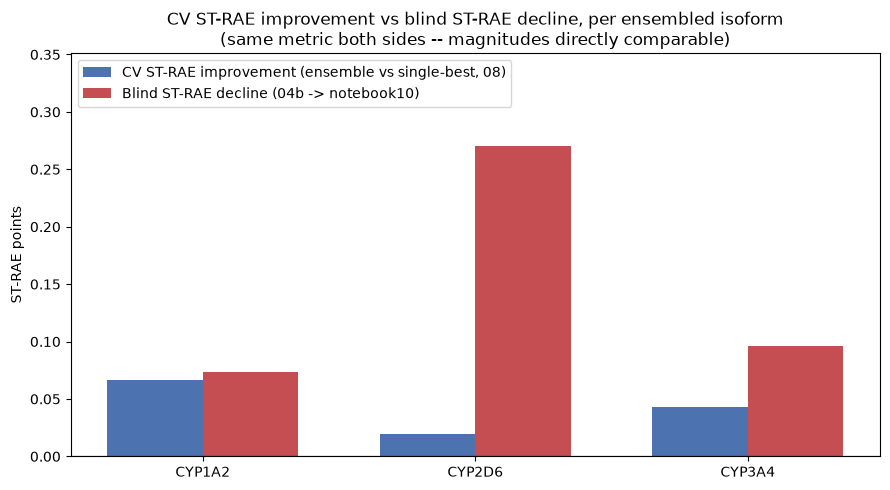

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/10b_blind_regression_investigation/figures/cv_margin_vs_blind_decline_starae.png


In [6]:
rows = []
for iso in ENSEMBLED_ISOFORMS:
    winning_combo = step3_summary.loc[step3_summary["isoform"] == iso, "winning_combo"].iloc[0]
    match = pairwise[(pairwise["isoform"] == iso) & (pairwise["combo"] == winning_combo)]
    cv_delta = float(match["delta_mean"].iloc[0])
    cv_p = float(match["p_value"].iloc[0])

    starae_04b = blind_starae(iso, "04b")
    starae_nb10 = blind_starae(iso, "notebook10")
    blind_starae_decline = starae_nb10 - starae_04b  # positive = got worse (ST-RAE: lower is better)

    rows.append({
        "isoform": iso,
        "cv_starae_margin": cv_delta,
        "cv_starae_pvalue": cv_p,
        "blind_starae_04b": starae_04b,
        "blind_starae_nb10": starae_nb10,
        "blind_starae_decline": blind_starae_decline,
    })

addendum1_df = pd.DataFrame(rows)
print("Addendum Section 1 -- CV ST-RAE margin vs blind ST-RAE decline (same metric both sides):")
print(addendum1_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(addendum1_df))
width = 0.35
cv_improvement = -addendum1_df["cv_starae_margin"]  # sign-flipped: positive = ensemble improved
ax.bar(x - width / 2, cv_improvement, width, color="#4C72B0", label="CV ST-RAE improvement (ensemble vs single-best, 08)")
ax.bar(x + width / 2, addendum1_df["blind_starae_decline"], width, color="#C44E52", label="Blind ST-RAE decline (04b -> notebook10)")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(addendum1_df["isoform"])
ax.set_ylabel("ST-RAE points")
ax.set_title("CV ST-RAE improvement vs blind ST-RAE decline, per ensembled isoform\n(same metric both sides -- magnitudes directly comparable)")
ax.set_ylim(top=addendum1_df["blind_starae_decline"].max() * 1.3)
ax.legend(loc="upper left")
plt.tight_layout()
fig_path = FIG_OUT / "cv_margin_vs_blind_decline_starae.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {fig_path}")

**What this shows:** now that both sides are the same metric, the comparison is direct: **in
every one of the three ensembled isoforms, the blind ST-RAE decline is larger than the entire
CV-validated ST-RAE improvement margin** — CYP1A2 (decline 0.074 vs. margin 0.066, ~1.1x),
CYP3A4 (decline 0.096 vs. margin 0.043, ~2.2x), and CYP2D6 (decline 0.270 vs. margin 0.020,
~13.8x). The ensemble's entire CV-measured advantage was erased on blind data in all three
cases, not merely eroded — a materially stronger statement than the original Section 1's
R²-based read could support, since that mixed CV ST-RAE with blind R² and couldn't compare
magnitudes directly at all.

### Addendum Section 2 — spread ratio vs ST-RAE decline (descriptive, n=4)

Same method as Section 2, with `blind_starae_decline` (`notebook10 − 04b` ST-RAE, positive =
got worse) in place of R² decline. Same descriptive-only framing: n=4, no correlation
coefficient or p-value computed on 4 points.

Addendum Section 2 -- spread ratio vs blind ST-RAE decline:
isoform  spread_ratio  blind_starae_decline
 CYP1A2      0.636469                0.0736
 CYP2C9      1.022909                0.0081
 CYP2D6      0.671832                0.2700
 CYP3A4      0.923037                0.0962


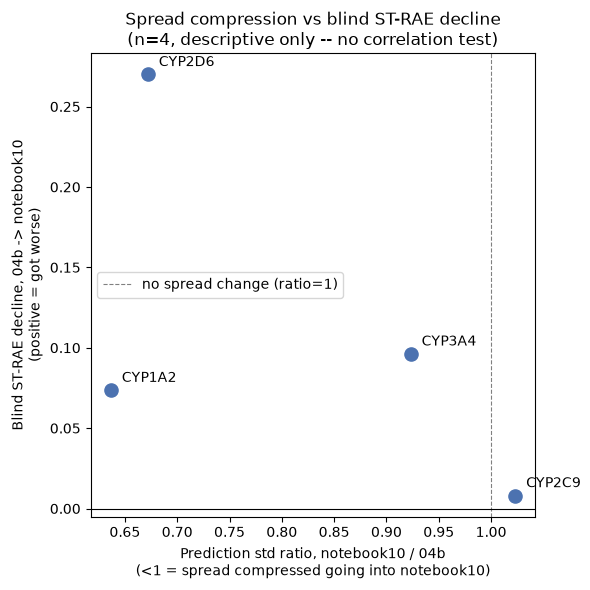

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/10b_blind_regression_investigation/figures/spread_compression_vs_decline_starae.png
wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/10b_blind_regression_investigation/summary_isoform_metrics.csv (4 rows, now including ST-RAE addendum columns)
isoform  std_train  std_04b  std_nb10  spread_ratio  blind_r2_decline                                                                winning_combo  cv_starae_margin  cv_starae_pvalue  std_ratio_to_train_04b  std_ratio_to_train_nb10  blind_starae_decline  blind_starae_04b  blind_starae_nb10
 CYP1A2   1.030476 0.845879  0.538375      0.636469            0.0773 chemprop_chemeleoninit+ecfp4_narrow__rf+chemeleon__rf+ecfp4_narrow__lightgbm         -0.066249      6.298245e-09                0.820862                 0.522453                0.0736            0.7114             0.7850
 CYP2C9   0.782295 0.760971  0.778405      1.022909           -0.0009                          

In [7]:
rows = []
for endpoint in REGRESSION_ENDPOINTS:
    iso = endpoint.split("_")[0]
    spread_ratio = float(analysis2_df.loc[analysis2_df["isoform"] == iso, "spread_ratio"].iloc[0])

    starae_04b = blind_starae(iso, "04b")
    starae_nb10 = blind_starae(iso, "notebook10")
    blind_starae_decline = starae_nb10 - starae_04b

    rows.append({"isoform": iso, "spread_ratio": spread_ratio, "blind_starae_decline": blind_starae_decline})

addendum2_df = pd.DataFrame(rows)
print("Addendum Section 2 -- spread ratio vs blind ST-RAE decline:")
print(addendum2_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(addendum2_df["spread_ratio"], addendum2_df["blind_starae_decline"], s=90, color="#4C72B0", zorder=3)
for _, r in addendum2_df.iterrows():
    ax.annotate(r["isoform"], (r["spread_ratio"], r["blind_starae_decline"]), textcoords="offset points", xytext=(8, 6))
ax.axvline(1.0, color="gray", linestyle="--", linewidth=0.8, label="no spread change (ratio=1)")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xlabel("Prediction std ratio, notebook10 / 04b\n(<1 = spread compressed going into notebook10)")
ax.set_ylabel("Blind ST-RAE decline, 04b -> notebook10\n(positive = got worse)")
ax.set_title("Spread compression vs blind ST-RAE decline\n(n=4, descriptive only -- no correlation test)")
ax.legend()
plt.tight_layout()
fig_path = FIG_OUT / "spread_compression_vs_decline_starae.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {fig_path}")

# Merge the addendum's ST-RAE numbers into summary_df and re-write the summary CSV so the
# persisted deliverable reflects both metrics, not just the original R2-based analysis.
# blind_starae_decline comes from addendum2_df (all 4 isoforms, incl. CYP2C9, which has no
# CV margin but does have a real blind ST-RAE decline); blind_starae_04b/nb10 are pulled
# directly for all 4 isoforms (not just the 3 in addendum1_df) so CYP2C9's real ST-RAE values
# are persisted too, even though it has no CV-margin row to go with them.
summary_df = summary_df.merge(
    addendum2_df[["isoform", "blind_starae_decline"]], on="isoform", how="left"
)
summary_df["blind_starae_04b"] = summary_df["isoform"].apply(lambda iso: blind_starae(iso, "04b"))
summary_df["blind_starae_nb10"] = summary_df["isoform"].apply(lambda iso: blind_starae(iso, "notebook10"))
summary_df.to_csv(summary_path, index=False)
print(f"wrote {summary_path} ({len(summary_df)} rows, now including ST-RAE addendum columns)")
print(summary_df.to_string(index=False))

**What this shows:** the ST-RAE-based read **disagrees with the R²-based read from Section 2 on
CYP1A2 vs. CYP3A4's relative ordering.** By R², CYP1A2 (heavier compression, ratio 0.636)
declined slightly more than CYP3A4 (milder compression, ratio 0.923) — 0.077 vs. 0.061 — loosely
consistent with *more* compression tracking *more* decline. By ST-RAE, that order **flips**:
CYP3A4 (milder compression) declined *more* (0.096) than CYP1A2 (heavier compression, 0.074) —
the isoform with *less* spread compression showing the *larger* decline, on the metric that
actually governs the leaderboard. That's not just "no clean dose-response" (Section 2's
R²-based conclusion) — for this pair, on the governing metric, the relationship runs backward.
CYP2D6 (most compressed, largest decline) and CYP2C9 (no compression, ~flat decline) stay
consistent across both metrics.

### Addendum synthesis — does the ST-RAE-based read agree with Section 4?

**It agrees with Section 4's headline verdict (spread compression is not a clean or sufficient
explanation), but arrives there via a different, and in one respect stronger, piece of
evidence.**

Section 4 (R²-based) concluded the hypothesis holds "partially, not cleanly" primarily because
CYP3A4's mild compression paired with a CYP1A2-*sized* decline. The ST-RAE-based read above
reaches the same overall verdict through a sharper finding: on the actual governing metric,
**CYP3A4's decline is larger than CYP1A2's despite having less compression** — a direct
inversion of the expected direction, not just a same-sized decline despite different
compression. That is stronger evidence against a compression-driven mechanism than Section 4
had available when it was written with R² as the only blind-side metric.

The addendum also adds something Section 4 could not compute at all: with the CV margin and
blind decline now expressed in the same units, **every ensembled isoform's blind ST-RAE decline
exceeds its entire CV-validated ST-RAE margin** (1.1x–13.8x, Addendum Section 1). This directly
strengthens open candidate (1) from Section 4 — a genuine CV→blind generalization gap unrelated
to spread — since the CV margins were never large enough to survive even a modest gap, measured
on the metric that actually determines the leaderboard score. Open candidate (2) from Section 4
(the `cyp-admet`→`cyp-admet-v2` environment change) is unaffected by this addendum either way —
it remains open, isoform-independent, and unconfirmed.

**Net effect on Section 4's conclusion:** unchanged in direction (spread compression is real but
not a clean or sufficient explanation), strengthened in one respect (the CYP1A2/CYP3A4 ordering
inversion under the true governing metric), and sharpened in another (the CV-margin-vs-decline
comparison is no longer a cross-metric approximation — it now directly shows the CV margins were
fully erased, in every ensembled isoform, on blind data).